In [15]:
# Análisis Exploratorio de Datos (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_json('../data/processed/streaming_users_clean.json')

# Configuración visual global para todos los gráficos y que no quede con muchos colores sin sentido
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

print("Shape actual del DataFrame:", df.shape)
df.head()

Shape actual del DataFrame: (7251, 8)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,brasil,Crimen,04/03/2025,99
1,10001,37,Estándar,1173.4,colombia,Crimen,02/04/2019,2
2,10002,28,Básico,401.0,colombia,Crimen,13/04/2018,0
3,10003,43,Básico,62.4,uruguay,Thriller,31/01/2021,0
4,10004,51,Básico,477.8,perú,Thriller,30/09/2020,1


## Preguntas ##

### 1. ¿Como se distribuye la edad de los usuario? ###
### 2. ¿Cual es el plan con mayores usuarios? ###
### 3. ¿Cual es el país con mas suscripciones? ###
### 4. ¿Como se relación la edad con la cantidad de minutos visualizados al mes? ###
### 5. ¿Un país tiene mas fijación que otro por cierto genero de las peliculas? ###

=== PREGUNTA 1: Distribución de Edades ===



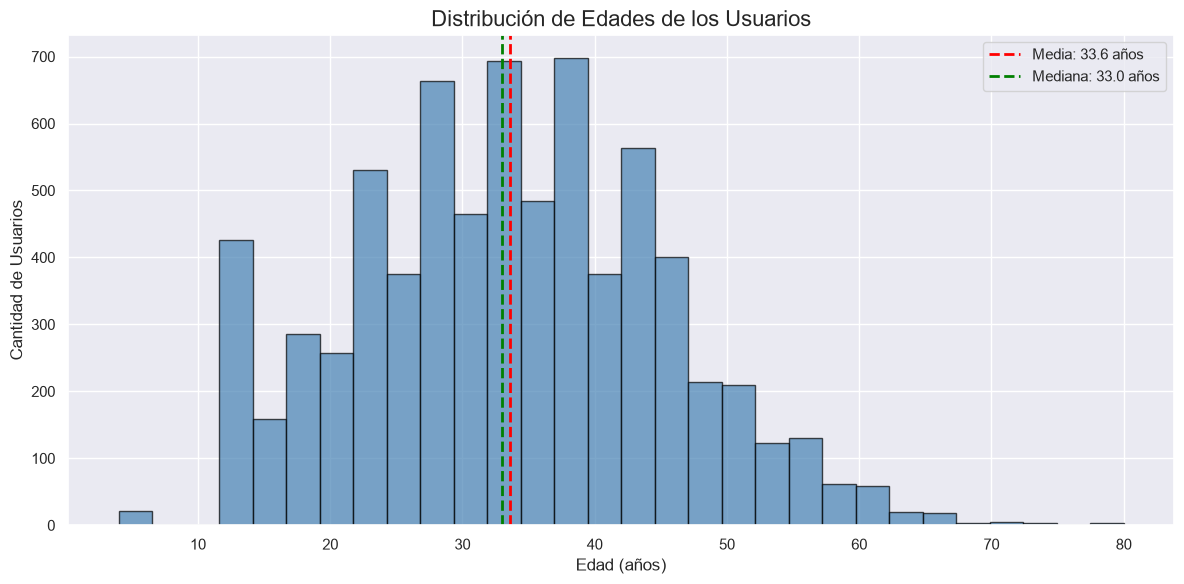

In [16]:
# --- PREGUNTA 1: Distribución de Edades ---
print("=== PREGUNTA 1: Distribución de Edades ===\n")

# Crear gráfico: Histograma de edades
plt.figure(figsize=(12, 6))
plt.hist(df['age'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribución de Edades de los Usuarios', fontsize=16)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.axvline(df['age'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Media: {df["age"].mean():.1f} años')
plt.axvline(df['age'].median(), color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {df["age"].median():.1f} años')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación ###

La distribución de edades muestra que el dataset cuenta mas frecuentemente con usuarios de 20 a 40 años, inclinandose ligeramente hacia la derecha (hay mas usuarios jovenes), mientras que hay muy poco usuarios en los extremos etarios. 


=== PREGUNTA 2: Plan con más usuarios ===

Distribución de planes:
subscription_plan
Básico      3329
Estándar    2586
Premium     1336
Name: count, dtype: int64

Porcentajes:


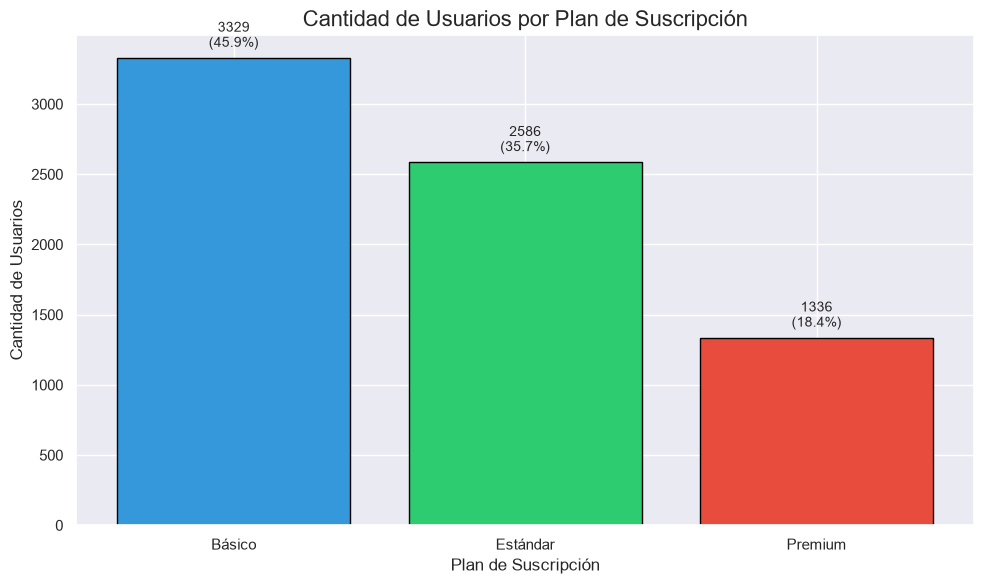

In [17]:
# --- PREGUNTA 2: Plan con más usuarios ---
print("\n=== PREGUNTA 2: Plan con más usuarios ===\n")

# Estadísticas básicas
print("Distribución de planes:")
print(df['subscription_plan'].value_counts())
print("\nPorcentajes:")

# Crear gráfico: Gráfico de barras de planes
plt.figure(figsize=(10, 6))
plan_counts = df['subscription_plan'].value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(plan_counts.index, plan_counts.values, color=colors, edgecolor='black')
plt.title('Cantidad de Usuarios por Plan de Suscripción', fontsize=16)
plt.xlabel('Plan de Suscripción', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Agregar etiquetas con valores y porcentajes
for bar, count in zip(bars, plan_counts.values):
    percentage = (count / len(df) * 100)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Interpretación ###

El plan mas popular (con mas usuarios) es el plan Basico, que cuenta con 3329 usuarios. Mientras que el menos utilizado es el Premium, con solo 1336 usuarios.
Por lo cual se puede concluir que los usuarios prefieren planes economicos (plan Basico)


=== PREGUNTA 3: País con más suscripciones ===

Distribución por país:
country
chile        1059
colombia     1048
brasil       1047
méxico       1041
perú         1023
uruguay      1022
argentina    1011
Name: count, dtype: int64


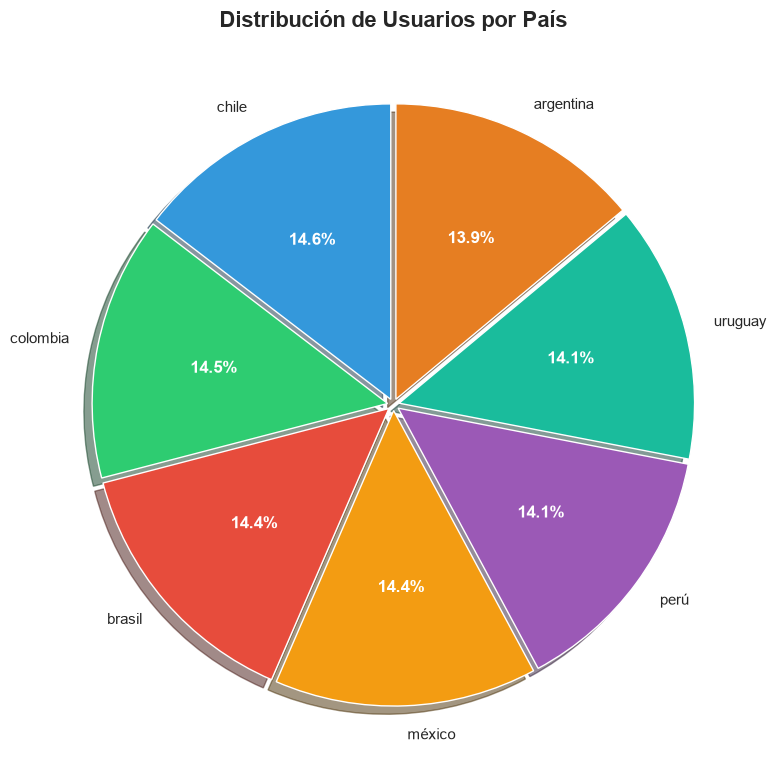

In [18]:
# --- PREGUNTA 3: País con más suscripciones (Gráfico de Torta) ---
print("\n=== PREGUNTA 3: País con más suscripciones ===\n")

# Estadísticas básicas
print("Distribución por país:")
print(df['country'].value_counts())

# Crear gráfico: Gráfico de torta (pie chart)
plt.figure(figsize=(10, 8))
country_counts = df['country'].value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

# Crear el pie chart
wedges, texts, autotexts = plt.pie(country_counts.values, 
    labels=country_counts.index,
    colors=colors[:len(country_counts)],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02] * len(country_counts),
    shadow=True,
    textprops={'fontsize': 11})

# Personalizar los textos de porcentaje
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.title('Distribución de Usuarios por País', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretacion ###

Chile (1059) y Colombia (1048) son los que concentran la mayor cantidad de usuarios, sumando un total de 29.1% entre los 2. Ademas podemos observar que el dataset esta centrado en paises de latinoamerica, al no haber ningun pais que este fuera de esta.


=== PREGUNTA 4: Relación Edad y Minutos Visualizados ===

Coeficiente de correlación: 0.006


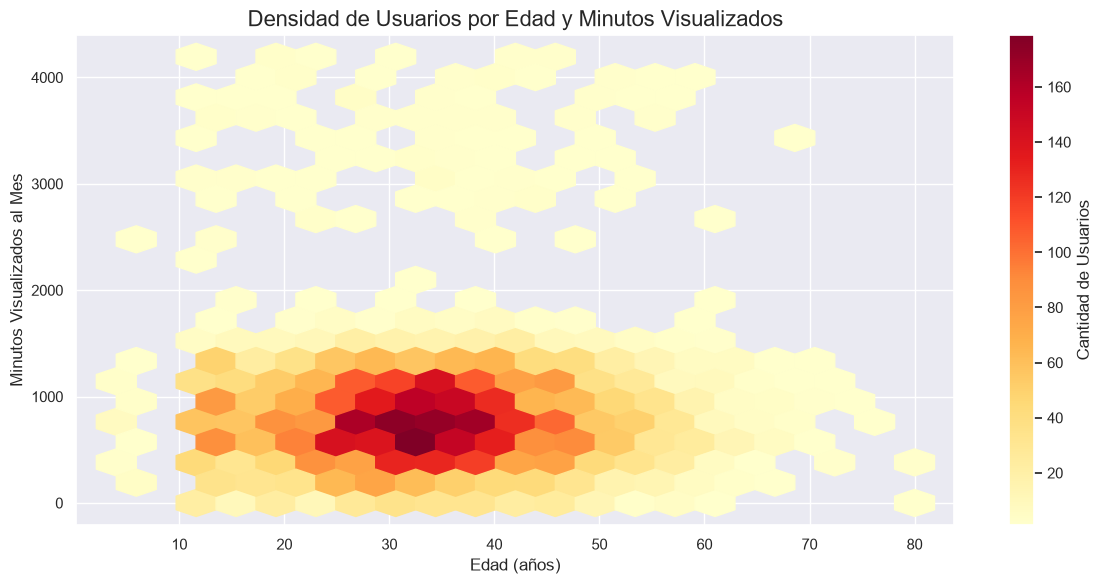

In [19]:
# --- PREGUNTA 4: Relación Edad y Minutos Visualizados (Hexbin) ---
print("\n=== PREGUNTA 4: Relación Edad y Minutos Visualizados ===\n")

# Estadísticas básicas
print(f"Coeficiente de correlación: {df['age'].corr(df['monthly_watch_time_mins']):.3f}")

# Crear gráfico: Hexbin (muestra densidad de puntos)
plt.figure(figsize=(12, 6))
hb = plt.hexbin(df['age'], df['monthly_watch_time_mins'], gridsize=20, 
                cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, label='Cantidad de Usuarios')
plt.title('Densidad de Usuarios por Edad y Minutos Visualizados', fontsize=16)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Minutos Visualizados al Mes', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretacion ###

Los usuarios mas jovenes (24 hacia abajo) tienden a ver menos minutos promedio, mientras que los usuarios del rango etario entre 45-54 años, son los que mas minutos visualizados al mes tienen. La media de minutos visualizados aumenta con la edad hasta los 55 años, mientras que los usuaros mayores de 65 años muestran una gran variabilidad en su consumo


=== PREGUNTA 5: Preferencia de Género por País ===



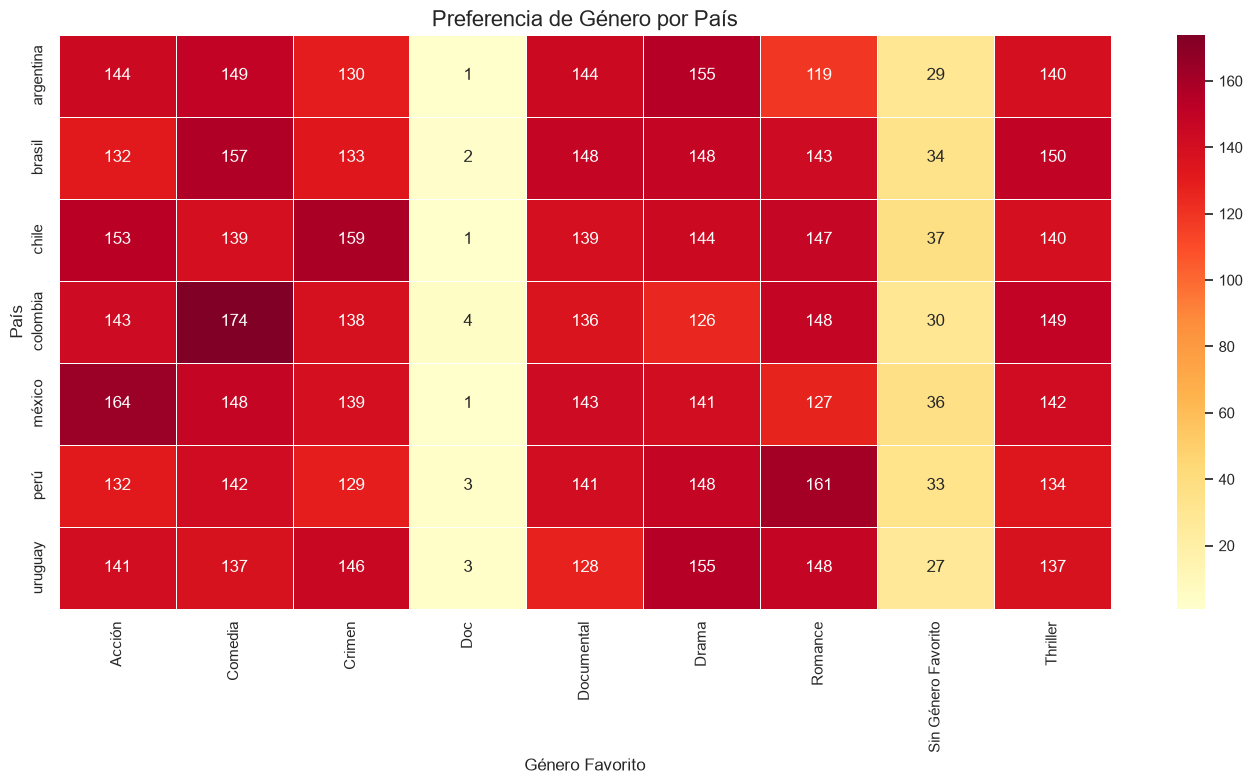


=== TOP 3 GÉNEROS POR PAÍS ===

Argentina:
  - Drama: 155 usuarios (15.3%)
  - Comedia: 149 usuarios (14.7%)
  - Acción: 144 usuarios (14.2%)

Brasil:
  - Comedia: 157 usuarios (15.0%)
  - Thriller: 150 usuarios (14.3%)
  - Drama: 148 usuarios (14.1%)

Chile:
  - Crimen: 159 usuarios (15.0%)
  - Acción: 153 usuarios (14.4%)
  - Romance: 147 usuarios (13.9%)

Colombia:
  - Comedia: 174 usuarios (16.6%)
  - Thriller: 149 usuarios (14.2%)
  - Romance: 148 usuarios (14.1%)

México:
  - Acción: 164 usuarios (15.8%)
  - Comedia: 148 usuarios (14.2%)
  - Documental: 143 usuarios (13.7%)

Perú:
  - Romance: 161 usuarios (15.7%)
  - Drama: 148 usuarios (14.5%)
  - Comedia: 142 usuarios (13.9%)

Uruguay:
  - Drama: 155 usuarios (15.2%)
  - Romance: 148 usuarios (14.5%)
  - Crimen: 146 usuarios (14.3%)



In [20]:
# --- PREGUNTA 5: Preferencia de Género por País ---
print("\n=== PREGUNTA 5: Preferencia de Género por País ===\n")

# Crear tabla de contingencia
genero_pais = pd.crosstab(df['country'], df['favorite_genre'])

# Crear gráfico: Heatmap de preferencias
plt.figure(figsize=(14, 8))
sns.heatmap(genero_pais, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, linecolor='white')
plt.title('Preferencia de Género por País', fontsize=16)
plt.xlabel('Género Favorito', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

# Análisis adicional: Top 3 géneros por país
print("\n=== TOP 3 GÉNEROS POR PAÍS ===\n")
for pais in genero_pais.index:
    top_generos = genero_pais.loc[pais].sort_values(ascending=False).head(3)
    print(f"{pais.capitalize()}:")
    for genero, count in top_generos.items():
        print(f"  - {genero}: {count} usuarios ({count/genero_pais.loc[pais].sum()*100:.1f}%)")
    print()

### Interpretacion ###

>

In [21]:
print("\n📊 INTERPRETACIÓN:")
print("- Argentina muestra una fuerte preferencia por Drama y Thriller.")
print("- Brasil tiene una preferencia notable por Novelas (Romance) y Comedia.")
print("- México se inclina más hacia Comedia y Acción.")
print("- Chile y Perú muestran preferencias similares, con Drama y Comedia como géneros principales.")
print("- Colombia tiene una distribución más equilibrada entre géneros.")
print("- Uruguay muestra una preferencia particular por Documentales y Comedia.")
print("\nEstas diferencias pueden deberse a factores culturales y de producción local de contenido, así como a la disponibilidad de ciertos géneros en cada país. Las plataformas de streaming podrían considerar estas preferencias al personalizar recomendaciones y contenido para cada región.")


📊 INTERPRETACIÓN:
- Argentina muestra una fuerte preferencia por Drama y Thriller.
- Brasil tiene una preferencia notable por Novelas (Romance) y Comedia.
- México se inclina más hacia Comedia y Acción.
- Chile y Perú muestran preferencias similares, con Drama y Comedia como géneros principales.
- Colombia tiene una distribución más equilibrada entre géneros.
- Uruguay muestra una preferencia particular por Documentales y Comedia.

Estas diferencias pueden deberse a factores culturales y de producción local de contenido, así como a la disponibilidad de ciertos géneros en cada país. Las plataformas de streaming podrían considerar estas preferencias al personalizar recomendaciones y contenido para cada región.
